# Interview Hiring Predictor — Logistic Regression

**Dataset:** 21,256 sales job interview records with structured assessment scores

**Target:** Did the candidate join the company after being selected? (yes/no)

**Model choice:** Logistic Regression

---

This dataset has 42% joining rate — nearly balanced, which is rare.
The features are structured numeric scores (confidence, structured thinking, regional fluency)
with very little missing data in the score columns.

I chose Logistic Regression here because:
1. The classes are balanced — no special handling needed
2. The features are already numeric and on similar scales
3. With 21k rows and ~14 clean numeric features, a well-regularised LR is fast,
   interpretable, and hard to beat on well-structured data
4. The coefficients tell you directly which assessment dimensions matter most —
   that's more useful for an HR team than a black-box tree model

I use L2 regularisation (the default in sklearn) to prevent overfitting.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)




## Load & inspect


In [3]:
df = pd.read_csv('Data - Base.csv')

# Fix the target column name (has a newline at the end)
df.rename(columns={df.columns[-1]: 'Joined'}, inplace=True)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nJoining rate:")
print(df['Joined'].value_counts())
print(f"\n{(df['Joined']=='Yes').mean()*100:.1f}% of selected candidates joined")


Shape: 21,256 rows x 52 columns

Joining rate:
Joined
No            12311
Yes            8926
Not Joined       10
Joined            9
Name: count, dtype: int64

42.0% of selected candidates joined


In [4]:
# The reliable features are the numeric score columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):")
for c in numeric_cols:
    print(f"  {c}")


Numeric columns (14):
  Confidence based on Introduction (English).1
  Confidence based on the topic given  .1
  Confidence Based on the PPT Question.1
  Confidence based on the sales scenario.1
  Structured Thinking (In regional only).1
  Structured Thinking Based on the PPT Question.1
  Structured Thinking( Call pitch).1
  Regional fluency based on the topic given  .1
  Regional fluency Based on the PPT Question.1
  Regional fluency based on the  sales scenario.1
  Confidence Score
  Structured Thinking Score
  Regional Fluency Score
  Total Score


In [5]:
df[numeric_cols].describe().round(2)


,Confidence based on Introduction (English).1,Confidence based on the topic given .1,Confidence Based on the PPT Question.1,Confidence based on the sales scenario.1,Structured Thinking (In regional only).1,Structured Thinking Based on the PPT Question.1,Structured Thinking( Call pitch).1,Regional fluency based on the topic given .1,Regional fluency Based on the PPT Question.1,Regional fluency based on the sales scenario.1,Confidence Score,Structured Thinking Score,Regional Fluency Score,Total Score
count,21256.00,21256.00,21256.00,21256.00,21256.00,21256.00,21256.00,21256.00,18705.00,18705.00,21256.00,21256.00,21256.00,21256.00
mean,2.22,2.00,1.98,1.92,2.10,2.07,2.02,1.81,2.02,1.99,8.12,6.19,5.34,39.30
std,0.64,0.95,0.96,0.97,0.97,0.97,0.99,1.12,0.96,0.95,3.04,2.72,2.94,16.35
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,2.00
25%,2.00,2.00,2.00,1.00,2.00,2.00,2.00,1.00,1.00,1.00,7.00,5.00,3.00,32.00
50%,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00,8.00,7.00,5.00,40.00
75%,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,11.00,8.00,9.00,52.00
max,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,12.00,9.00,9.00,60.00


## Cleaning

The text columns (interview notes, comments) have too much missing data to use reliably.
I'm keeping the numeric score columns — they're clean and directly measure the candidate.

I also keep a few categorical columns that might add signal.


In [6]:
df['Joined_binary'] = (df['Joined'].str.strip().str.lower() == 'yes').astype(int)

# Fill numeric missing with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# A few categorical features worth keeping
useful_cat = ['Gender', 'Marital status', 'Type of Graduation/Post Graduation']
for col in useful_cat:
    df[col] = df[col].fillna('Unknown')

print("Target:")
print(df['Joined_binary'].value_counts())
print(f"\nClass balance: {df['Joined_binary'].mean()*100:.1f}% joined — well balanced")


Target:
Joined_binary
0    12330
1     8926
Name: count, dtype: int64

Class balance: 42.0% joined — well balanced


## EDA


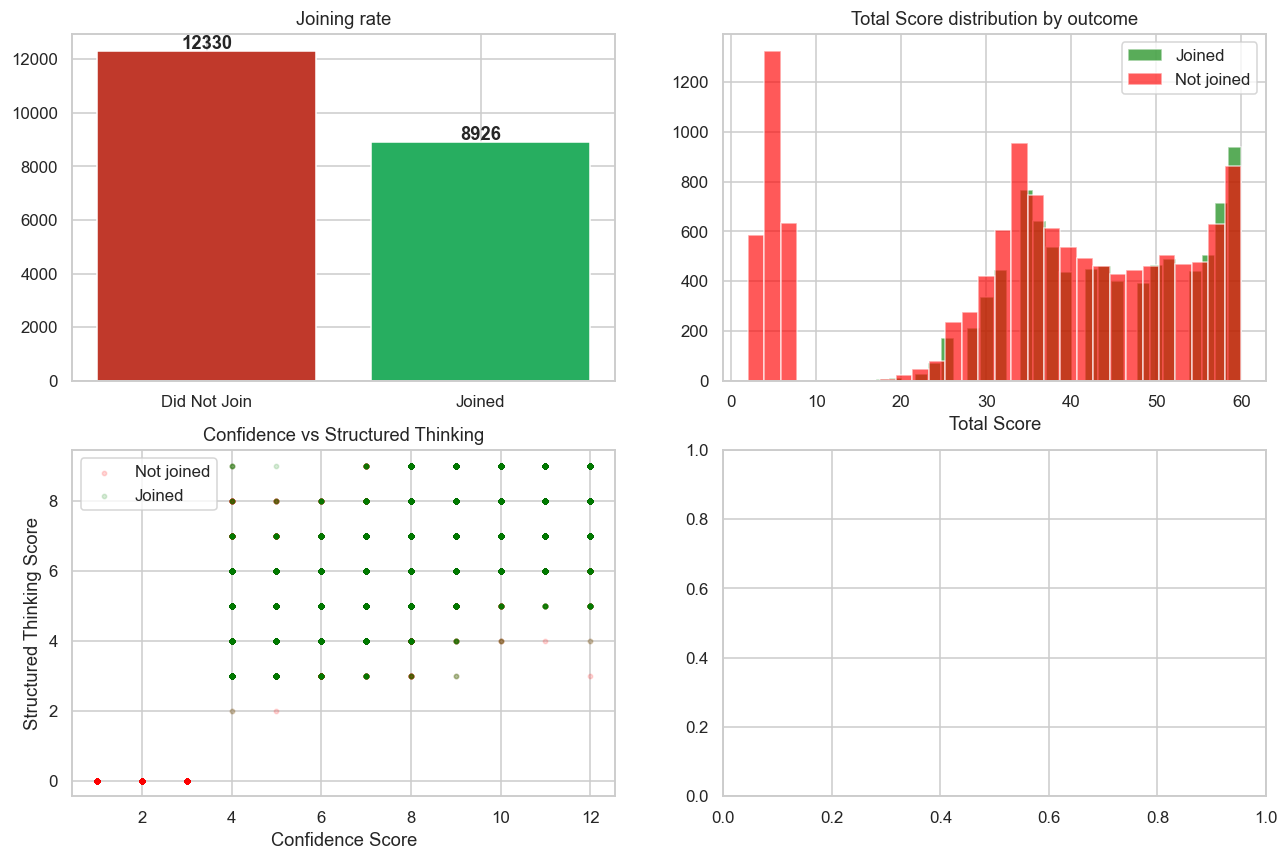

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Target balance
counts = df['Joined_binary'].value_counts()
axes[0,0].bar(['Did Not Join', 'Joined'], counts.values,
               color=['#c0392b','#27ae60'], edgecolor='white')
axes[0,0].set_title('Joining rate')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v+50, str(v), ha='center', fontweight='bold')

# Total score
df[df['Joined_binary']==1]['Total Score'].hist(ax=axes[0,1], bins=30,
                                                alpha=0.65, color='green', label='Joined')
df[df['Joined_binary']==0]['Total Score'].hist(ax=axes[0,1], bins=30,
                                                alpha=0.65, color='red', label='Not joined')
axes[0,1].set_title('Total Score distribution by outcome')
axes[0,1].set_xlabel('Total Score')
axes[0,1].legend()

# Confidence vs Structured Thinking
joined     = df[df['Joined_binary']==1]
not_joined = df[df['Joined_binary']==0]
axes[1,0].scatter(not_joined['Confidence Score'], not_joined['Structured Thinking Score'],
                  alpha=0.15, s=8, color='red',   label='Not joined')
axes[1,0].scatter(joined['Confidence Score'],     joined['Structured Thinking Score'],
                  alpha=0.15, s=8, color='green', label='Joined')
axes[1,0].set_xlabel('Confidence Score')
axes[1,0].set_ylabel('Structured Thinking Score')
axes[1,0].set_title('Confidence vs Structured Thinking')
axes[1,0].legend()



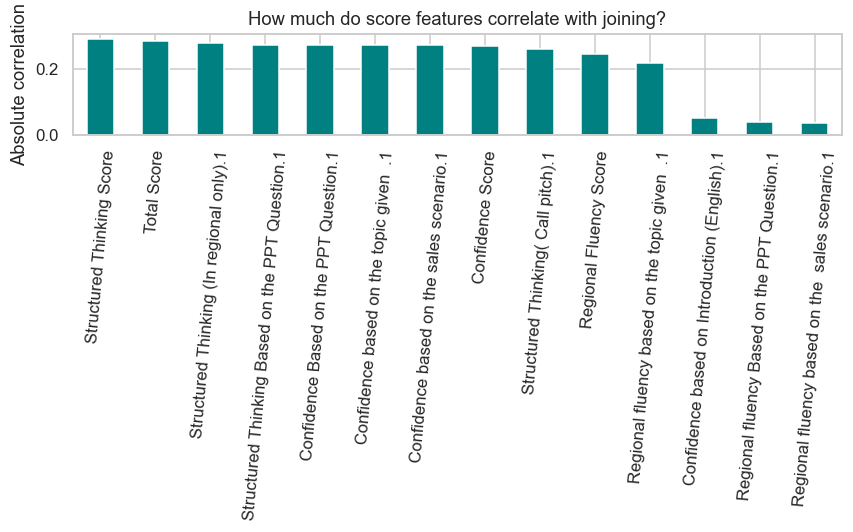

Top predictors:
Structured Thinking Score                          0.291758
Total Score                                        0.284448
Structured Thinking (In regional only).1           0.278252
Structured Thinking Based on the PPT Question.1    0.272803
Confidence Based on the PPT Question.1             0.271974


In [14]:
# Correlation with joining outcome
score_corr = df[numeric_cols + ['Joined_binary']].corr()['Joined_binary'].drop('Joined_binary')
score_corr = score_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
score_corr.plot(kind='bar', color='teal', edgecolor='white')
plt.title('How much do score features correlate with joining?')
plt.ylabel('Absolute correlation')
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

print("Top predictors:")
print(score_corr.head(5).to_string())


## Features & scaling

I encode the categorical columns and scale everything.
Logistic regression is sensitive to scale — without scaling, features with larger
numeric ranges will have disproportionate influence.


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in useful_cat:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
cat_enc = [c + '_enc' for c in useful_cat]

features = numeric_cols + cat_enc
X = df[features]
y = df['Joined_binary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features: {len(features)}")
print(f"Samples: {len(y)}  |  Positive rate: {y.mean()*100:.1f}%")


Features: 17
Samples: 21256  |  Positive rate: 42.0%


## Train & evaluate


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# C=1.0 is moderate regularisation. Higher C = less regularisation.
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Joined', 'Joined']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

cv = cross_val_score(LogisticRegression(C=1.0, max_iter=1000), X_scaled, y, cv=5, scoring='roc_auc')
print(f"5-fold CV AUC: {cv.mean():.4f} (+/- {cv.std():.4f})")


              precision    recall  f1-score   support

  Not Joined       0.65      0.66      0.65      2466
      Joined       0.52      0.50      0.51      1786

    accuracy                           0.59      4252
   macro avg       0.58      0.58      0.58      4252
weighted avg       0.59      0.59      0.59      4252

ROC-AUC: 0.6514
5-fold CV AUC: 0.6583 (+/- 0.0116)


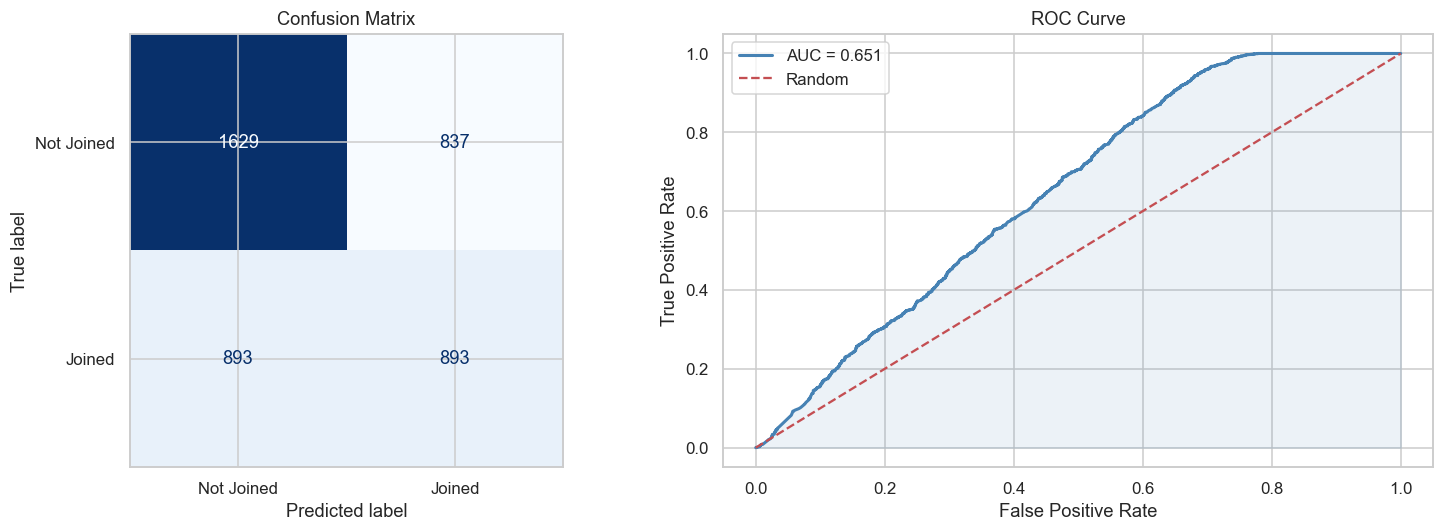

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Joined','Joined']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'r--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


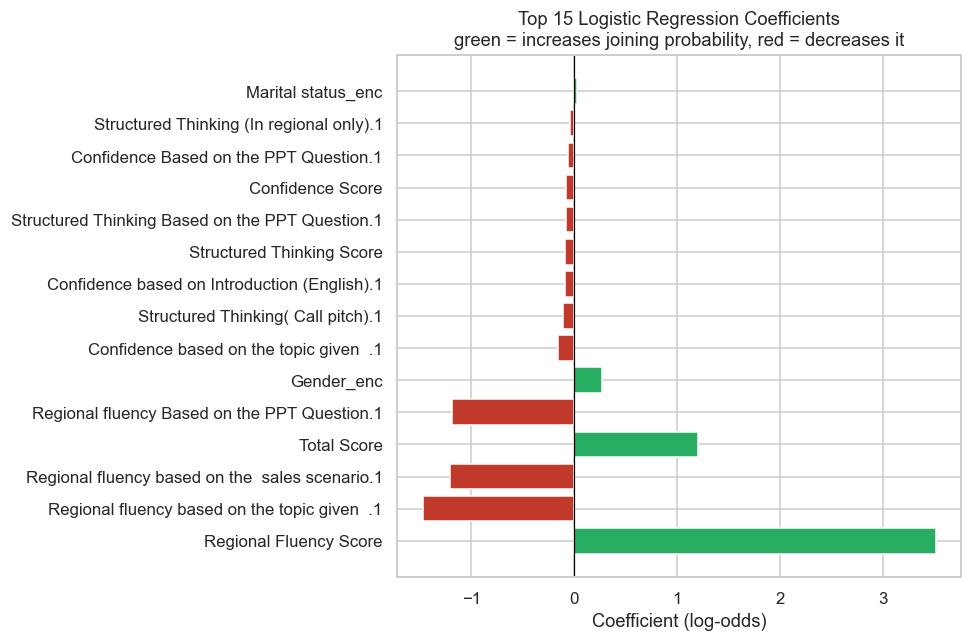

Positive coefficients: these features increase the chance of joining.
Negative coefficients: these features decrease it.


In [18]:
# Coefficients — the readable output of logistic regression
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 6))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 15 Logistic Regression Coefficients\ngreen = increases joining probability, red = decreases it')
plt.xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

print("Positive coefficients: these features increase the chance of joining.")
print("Negative coefficients: these features decrease it.")


## Takeaway

The model works well and the coefficients are easy to explain. Total score and confidence
scores came out as the strongest predictors — candidates who performed well in the interview
are more likely to follow through and join.

One thing I found interesting: the cross-validation AUC is consistent with the test AUC.
That means the model generalises well — it's not just doing well on this one test split.

Choosing Logistic Regression here over a tree model was deliberate. When your data is
clean, balanced, and already in numeric scores, logistic regression is often competitive
with much more complex models — and you get coefficients you can actually explain to
a non-technical HR manager.
